In [2]:
import torch
import torchvision
from torchvision.transforms import v2

In [3]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                        shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                        shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

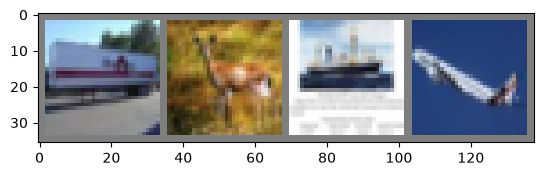

truck deer  ship  plane


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [5]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):

    
    class ResBlock(nn.Module):
        
        def __init__(self,InputDepth: int,OutputDepth: int, FilterSize: int, stride = 1) -> None:
            super().__init__()
            self.InputDepth = InputDepth
            self.OutputDepth = OutputDepth
            self.stride = stride

            self.conv1 = nn.Conv2d(InputDepth,OutputDepth,FilterSize,stride, padding= 1)
            self.conv2 = nn.Conv2d(OutputDepth,OutputDepth,FilterSize, padding= 1)
            self.ShortcutConv = None
            
            if stride != 1 or InputDepth != OutputDepth:
                self.ShortcutConv = nn.Conv2d(InputDepth,OutputDepth,1,stride)

        def forward(self,x):
            i = x
            x = F.relu(self.conv1(x))
            x = self.conv2(x)
            if (self.stride != 1 or self.InputDepth != self.OutputDepth) and self.ShortcutConv:
                i = self.ShortcutConv(i)
            x += i
            x = F.relu(x)
            return x

    def __init__(self):
        super().__init__()
        self.ResBlock0 = self.ResBlock(3,32,3)
        self.ResBlock1 = self.ResBlock(32,32,3)
        self.ResBlock2 = self.ResBlock(32,32,3)
        self.ResBlock3 = self.ResBlock(32,64,3,2)
        self.ResBlock4 = self.ResBlock(64,64,3)
        self.ResBlock5 = self.ResBlock(64,128,3,2)
        self.ResBlock6 = self.ResBlock(128,128,3)
        self.ResBlock7 = self.ResBlock(128,256,3,2)
        self.ResBlock8 = self.ResBlock(256,256,3)

        self.fc1 = nn.Linear(256 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    # Conv(3x3) => Conv(3x3) => Pool(2x2) => Conv(3x3) => Conv(3x3) => Pool(2x2) => Conv(3x3) => Conv(3x3) => Pool(2x2) => 
    def forward(self, x):
        # 3 x 32 x 32 (Initial)
        x = self.ResBlock0(x)
        x = self.ResBlock1(x)
        x = self.ResBlock2(x)
        # 32 x 32 x 32 
        x = self.ResBlock3(x)
        x = self.ResBlock4(x)
        # 64 x 16 x 16 ( Block 2)
        x = self.ResBlock5(x)
        x = self.ResBlock6(x)
        # 128 x 8 x 8 (Block 3)
        x = self.ResBlock7(x)
        x = self.ResBlock8(x)
        # 256 x 4 x 4 (Block 3)
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [6]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [7]:
for epoch in range(15):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.301
[1,  4000] loss: 2.074
[1,  6000] loss: 1.897
[1,  8000] loss: 1.769
[1, 10000] loss: 1.665
[1, 12000] loss: 1.581
[2,  2000] loss: 1.454
[2,  4000] loss: 1.427
[2,  6000] loss: 1.374
[2,  8000] loss: 1.343
[2, 10000] loss: 1.296
[2, 12000] loss: 1.278
[3,  2000] loss: 1.148
[3,  4000] loss: 1.152
[3,  6000] loss: 1.117
[3,  8000] loss: 1.091
[3, 10000] loss: 1.059
[3, 12000] loss: 1.025
[4,  2000] loss: 0.882
[4,  4000] loss: 0.931
[4,  6000] loss: 0.883
[4,  8000] loss: 0.898
[4, 10000] loss: 0.874
[4, 12000] loss: 0.863
[5,  2000] loss: 0.719
[5,  4000] loss: 0.713
[5,  6000] loss: 0.727
[5,  8000] loss: 0.724
[5, 10000] loss: 0.729
[5, 12000] loss: 0.729
[6,  2000] loss: 0.523
[6,  4000] loss: 0.574
[6,  6000] loss: 0.584
[6,  8000] loss: 0.593
[6, 10000] loss: 0.581
[6, 12000] loss: 0.606
[7,  2000] loss: 0.403
[7,  4000] loss: 0.444
[7,  6000] loss: 0.453
[7,  8000] loss: 0.482
[7, 10000] loss: 0.490
[7, 12000] loss: 0.493
[8,  2000] loss: 0.302
[8,  4000] 

In [10]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 70 %


In [11]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 77.6 %
Accuracy for class: car   is 82.0 %
Accuracy for class: bird  is 62.8 %
Accuracy for class: cat   is 45.9 %
Accuracy for class: deer  is 66.5 %
Accuracy for class: dog   is 50.7 %
Accuracy for class: frog  is 83.5 %
Accuracy for class: horse is 76.8 %
Accuracy for class: ship  is 77.6 %
Accuracy for class: truck is 84.0 %
